<a href="https://colab.research.google.com/github/JhonRoy28/COM242_CCMACLRL/blob/main/Gamboa_Exercise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [71]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

data = {
    "name": [
        "Roy", "Alecks", "Bench", "Franz", "Leona", "Nicolai",
        "Jomari", "Jules", "Donita", "Jade", "Raiden", "James",
        "Ace", "Venti", "Nahida"
    ],
    "Followers": [
        90, 340, 45, 610, 25, 480,
        60, 720, 110, 390, 55, 260,
        140, 505, 30
    ],
    "friends": [
        35, 190, 20, 350, 15, 300,
        28, 420, 65, 220, 22, 150,
        80, 310, 18
    ],
    "Personality": [
        0, 1, 0, 1, 0, 1,
        0, 1, 0, 1, 0, 1,
        0, 1, 0
    ]
}

df = pd.DataFrame(data)

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [72]:
df.head()

,name,Followers,friends,Personality
0,Roy,90,35,0
1,Alecks,340,190,1
2,Bench,45,20,0
3,Franz,610,350,1
4,Leona,25,15,0


Display the summary of all the features of the dataset using `.info()`

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   name         15 non-null     object
 1   Followers    15 non-null     int64 
 2   friends      15 non-null     int64 
 3   Personality  15 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 612.0+ bytes


Display the total number of samples from each label using `.value_counts()`

In [74]:
df['Personality'].value_counts()

,count
Personality,
0,8
1,7


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

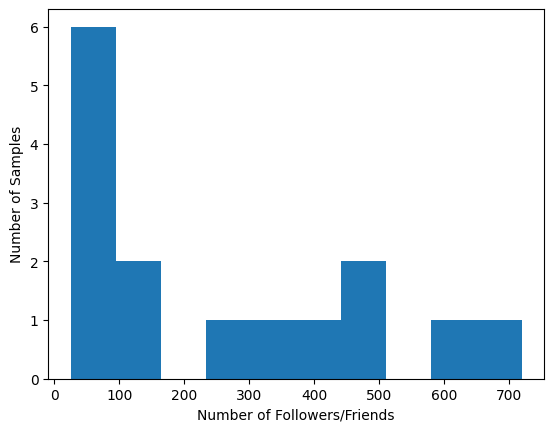

In [75]:
plt.hist(df['Followers'])
plt.xlabel('Number of Followers/Friends')
plt.ylabel('Number of Samples')
plt.show()

Remove the name column using `drop()` method

In [76]:
df = df.drop('name', axis=1)

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [77]:
X = df.drop('Personality', axis=1).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [78]:
y = df['Personality'].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Display the dimensions of each variables using `.shape()`

In [80]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12, 2)
(3, 2)
(12,)
(3,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [81]:
knn = KNeighborsClassifier(n_neighbors=5)

Train the model using the `.fit()`

In [82]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

Test the model using the `.predict()`

In [83]:
y_pred = knn.predict(X_test)

## E. Evaluate the model

Create a confusion matrix

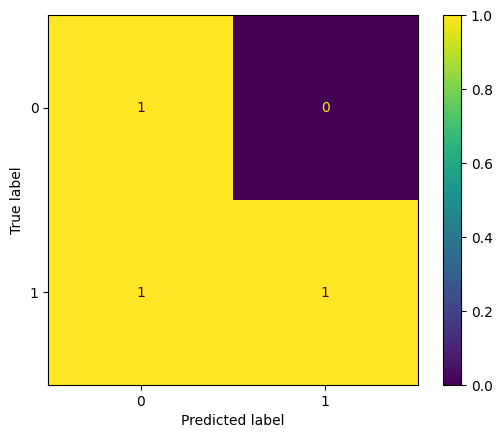

In [84]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Display the accuracy

In [85]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.6666666666666666


Display the precision

In [86]:
precision = precision_score(y_test, y_pred)
print(precision)

1.0


Display the recall

In [87]:
recall = recall_score(y_test, y_pred)
print(recall)

0.5


Display the f1-score

In [88]:
f1 = f1_score(y_test, y_pred)
print(f1)

0.6666666666666666


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [89]:
my_data = [[300, 150]]
prediction = knn.predict(my_data)

if prediction[0] == 0:
    print("Predicted Personality: Introvert")
else:
    print("Predicted Personality: Extrovert")

Predicted Personality: Extrovert
